In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
import itertools
import sys
sys.path.insert(0, os.path.dirname(os.getcwd()))
import liset_tk.lists_sessions as lists_sessions
# Set style
sns.set_style("whitegrid")
# plt.rcParams.update({'font.size': 12})
plt.rcParams['svg.fonttype'] = 'none'
from barplot_brackets import *

In [3]:
# Load Dutta Data
results_path = os.path.join("spikes", "crossval_results.csv")

if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    print(f"Loaded {len(df)} rows from {results_path}")
    
    # Preprocessing
    # Rename ADAPT to Adapt for consistency
    if "ADAPT" in df.columns:
        df.rename(columns={"ADAPT": "Adapt"}, inplace=True)
        
    print("Columns:", df.columns.tolist())
    print("Threshold:", sorted(df["Threshold"].unique()))
    
    display(df.head())
else:
    print(f"File not found: {results_path}. Please run process_live_spikes.py first.")

Loaded 340 rows from spikes\crossval_results.csv
Columns: ['GT', 'Detections', 'Session', 'Threshold', 'TP', 'FP', 'FN', 'Precision', 'Recall', 'F1', 'Mean_Latency', 'Num_Spikes', 'Num_Ripples']
Threshold: [nan]


,GT,Detections,Session,Threshold,TP,FP,FN,Precision,Recall,F1,Mean_Latency,Num_Spikes,Num_Ripples
0,SNN_GT,RippleNet_GT,2025-09-22_17-42-27,NaN,40,30,12,0.571429,0.769231,0.655738,-14.250000,70,52
1,SNN_GT,RippleNet_GT,2025-09-24_11-34-51,NaN,8,13,13,0.380952,0.380952,0.380952,-21.200000,21,21
2,SNN_GT,RippleNet_GT,2025-09-22_17-55-26,NaN,144,57,62,0.716418,0.699029,0.707617,-9.137500,207,206
3,SNN_GT,RippleNet_GT,2025-09-25_11-21-53,NaN,100,118,41,0.458716,0.709220,0.557103,-12.510000,225,141
4,SNN_GT,RippleNet_GT,2025-09-24_14-22-55,NaN,278,6,37,0.978873,0.882540,0.928214,6.176259,286,315


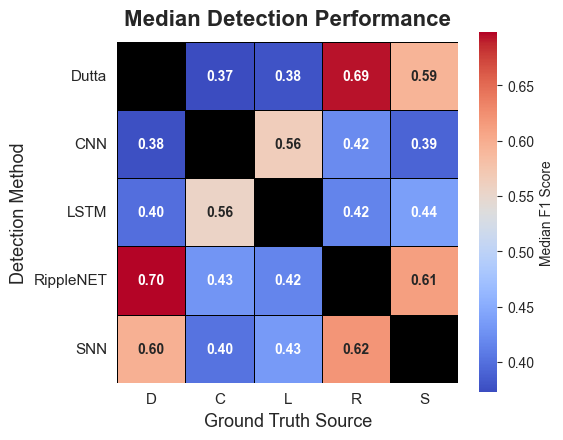

In [35]:
# Create a pivot table: Rows=Detections, Cols=GT, Values=Median F1
heatmap_data = df.pivot_table(index='Detections', columns='GT', values='F1', aggfunc='median')

# Rename for clarity (one-time, safer than manual ticks)
heatmap_data = heatmap_data.rename(
    columns=dict(zip(heatmap_data.columns, ["D", "C", "L", "R", "S"])),
    index=dict(zip(heatmap_data.index,
                   ["Dutta", "CNN", "LSTM", "RippleNET", "SNN"]))
)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.set_facecolor("#000000")  # deeper, less saturated purple

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",          # perceptually uniform
    # vmin=0.0, vmax=1.0,   # consistent F1 scale
    square=True,
    linewidths=0.6,
    linecolor="black",
    cbar_kws={
        "label": "Median F1 Score",
        "shrink": 0.85
    },
    annot_kws={"size": 10, "weight": "bold"},
    ax=ax
)

ax.set_title("Median Detection Performance", fontsize=16, weight="bold", pad=12)
ax.set_xlabel("Ground Truth Source", fontsize=13)
ax.set_ylabel("Detection Method", fontsize=13)

ax.tick_params(axis='x', labelrotation=0, labelsize=11)
ax.tick_params(axis='y', labelsize=11, labelrotation=0)

ax.set_aspect("equal")
ax.grid(False)